Leukemia Classification Project - Phase 2: Autoencoder Pretraining
🎯 Phase 2 Overview

Objective: Train a deep autoencoder on TCGA pan-cancer data to learn compressed gene expression representations that will serve as the foundation for transfer learning to leukemia classification.

Input Data Ready:

TCGA Dataset: tcga_filtered.csv (10,535 samples × 20,034 genes)

Memory Constraints: 6GB RAM system

Goal: Learn biological representations transferable to leukemia

2.1 Memory-Optimized Data Loading & Preprocessing


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import joblib
import gc
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Memory optimization settings
tf.config.set_soft_device_placement(True)
tf.keras.mixed_precision.set_global_policy('float32')

def load_and_preprocess_data():
    """Load and preprocess TCGA gene expression data in a memory-efficient way.

    This function reads the TCGA gene-expression CSV, converts values to
    float32 to reduce memory usage, standardizes the features using
    `StandardScaler`, and saves the fitted scaler to `models/scaler.joblib`
    for later use with leukemia data.

    Args:
        None

    Returns:
        Tuple[np.ndarray, sklearn.preprocessing.StandardScaler]:
            - X_scaled: Standardized gene-expression array (float32).
            - scaler: Fitted StandardScaler instance saved for later use.

    Raises:
        FileNotFoundError: If the expected TCGA CSV file is not found.
    """

    
    print("🔹 Loading TCGA data for autoencoder training...")
    
    # Load in chunks if memory becomes issue
    tcga_path = "data/processed/tcga_filtered.csv"  # No ".." needed in Colab
    tcga_df = pd.read_csv(tcga_path, index_col=0)
    
    print(f"✅ TCGA data loaded: {tcga_df.shape}")
    
    # Convert to float32 to save memory
    X_train = tcga_df.values.astype('float32')
    
    # Free memory
    del tcga_df
    gc.collect()
    
    # Standardize data - crucial for autoencoder convergence
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    print("🔹 Standardizing gene expression data...")
    X_scaled = scaler.fit_transform(X_train)
    
    # Save scaler for leukemia data transformation
    models_dir = Path("models")
    models_dir.mkdir(exist_ok=True)
    joblib.dump(scaler, models_dir / "scaler.joblib")
    print("✅ Scaler saved for future use")
    
    return X_scaled, scaler

# Load data
X_train, scaler = load_and_preprocess_data()
print(f"🎯 Final training data: {X_train.shape}, dtype: {X_train.dtype}")

🔹 Loading TCGA data for autoencoder training...
✅ TCGA data loaded: (10535, 20034)
🔹 Standardizing gene expression data...
✅ Scaler saved for future use
🎯 Final training data: (10535, 20034), dtype: float32


2.2 Memory-Optimized Autoencoder Architecture


In [ ]:
def build_faster_autoencoder(input_dim, encoding_dim=30):
    """Create a smaller, memory- and compute-friendly autoencoder model.

    The smaller architecture reduces parameter count and memory footprint
    while providing a latent bottleneck useful for transfer learning.

    Args:
        input_dim (int): Number of input features (genes).
        encoding_dim (int): Size of the latent bottleneck (default: 30).

    Returns:
        Tuple[keras.Model, keras.Model]:
            - autoencoder: Full autoencoder model mapping input -> reconstruction.
            - encoder: Encoder model mapping input -> latent representation.

    Raises:
        ValueError: If `input_dim` is not a positive integer.
    """
    
    inp = keras.Input(shape=(input_dim,), name="gene_expression_input")
    
    # Smaller encoder
    x = layers.Dense(500, activation='relu', name="encoder_dense_1")(inp)
    x = layers.BatchNormalization(name="encoder_bn_1")(x)
    
    x = layers.Dense(100, activation='relu', name="encoder_dense_2")(x)
    x = layers.BatchNormalization(name="encoder_bn_2")(x)
    
    # Smaller bottleneck
    latent = layers.Dense(encoding_dim, activation='relu', name="latent_bottleneck")(x)
    
    # Smaller decoder
    x = layers.Dense(100, activation='relu', name="decoder_dense_1")(latent)
    x = layers.BatchNormalization(name="decoder_bn_1")(x)
    
    x = layers.Dense(500, activation='relu', name="decoder_dense_2")(x)
    x = layers.BatchNormalization(name="decoder_bn_2")(x)
    
    out = layers.Dense(input_dim, activation='linear', name="reconstructed_output")(x)
    
    autoencoder = keras.Model(inp, out, name="GeneExpression_Autoencoder")
    encoder = keras.Model(inp, latent, name="Encoder")
    
    return autoencoder, encoder

# Build smaller model
input_dim = X_train.shape[1]
print("🔹 Building FASTER autoencoder architecture...")
autoencoder, encoder = build_faster_autoencoder(input_dim, encoding_dim=30)

# Compile with higher learning rate
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

print("✅ Smaller autoencoder built - will train much faster!")
autoencoder.summary()

🔹 Building FASTER autoencoder architecture...
✅ Smaller autoencoder built - will train much faster!


Model: "GeneExpression_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gene_expression_input           │ (None, 20034)          │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 500)            │    10,017,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_1                    │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_2                    │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_bottleneck (Dense)       │ (None, 30)             │         3,030 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 100)            │         3,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_1                    │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 500)            │        50,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_2                    │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_output (Dense)    │ (None, 20034)          │    10,037,034 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,166,064 (76.93 MB)

 Trainable params: 20,163,664 (76.92 MB)

 Non-trainable params: 2,400 (9.38 KB)

2.3 Memory-Optimized Training Strategy


In [ ]:
def train_autoencoder_faster(X_train, autoencoder, validation_split=0.1):
    """Train the autoencoder with settings optimized for speed and memory.

    Uses early stopping, ReduceLROnPlateau and ModelCheckpoint callbacks; a
    larger batch size and reduced maximum epochs are chosen to shorten
    wall-clock training time on constrained hardware.

    Args:
        X_train (np.ndarray): Training data (samples x features), standardized.
        autoencoder (keras.Model): Compiled autoencoder model to be trained.
        validation_split (float): Fraction of data to reserve for validation.

    Returns:
        keras.callbacks.History: Keras History object with training metrics.

    Raises:
        ValueError: If `validation_split` is not in (0, 1).
    """
    
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
        keras.callbacks.ModelCheckpoint("models/autoencoder_checkpoint.h5", save_best_only=True)
    ]
    
    print("🚀 Starting FASTER autoencoder training...")
    print(f"📊 Training samples: {int(X_train.shape[0] * (1-validation_split)):,}")
    print(f"📊 Validation samples: {int(X_train.shape[0] * validation_split):,}")
    
    # Larger batch size = faster training
    batch_size = 32
    
    history = autoencoder.fit(
        X_train, X_train,
        epochs=50,  # Reduced max epochs
        batch_size=batch_size,
        validation_split=validation_split,
        callbacks=callbacks,
        verbose=1
    )
    
    return history

# Train with faster settings
history = train_autoencoder_faster(X_train, autoencoder)

🚀 Starting FASTER autoencoder training...
📊 Training samples: 9,481
📊 Validation samples: 1,053
Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.6402 - mae: 0.5815

297/297 ━━━━━━━━━━━━━━━━━━━━ 65s 198ms/step - loss: 0.5515 - mae: 0.5395 - val_loss: 0.4546 - val_mae: 0.4907 - learning_rate: 0.0010
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 55s 186ms/step - loss: 0.4754 - mae: 0.4979 - val_loss: 0.4568 - val_mae: 0.4890 - learning_rate: 0.0010
Epoch 3/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.4865 - mae: 0.4944

297/297 ━━━━━━━━━━━━━━━━━━━━ 88s 207ms/step - loss: 0.4562 - mae: 0.4866 - val_loss: 0.4125 - val_mae: 0.4596 - learning_rate: 0.0010
Epoch 4/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.4387 - mae: 0.4771

297/297 ━━━━━━━━━━━━━━━━━━━━ 77s 188ms/step - loss: 0.4409 - mae: 0.4773 - val_loss: 0.4030 - val_mae: 0.4528 - learning_rate: 0.0010
Epoch 5/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 0.4315 - mae: 0.4712

297/297 ━━━━━━━━━━━━━━━━━━━━ 58s 196ms/step - loss: 0.4311 - mae: 0.4717 - val_loss: 0.3931 - val_mae: 0.4454 - learning_rate: 0.0010
Epoch 6/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 60s 202ms/step - loss: 0.4254 - mae: 0.4683 - val_loss: 0.4038 - val_mae: 0.4518 - learning_rate: 0.0010
Epoch 7/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 66s 221ms/step - loss: 0.4175 - mae: 0.4628 - val_loss: 0.4140 - val_mae: 0.4617 - learning_rate: 0.0010
Epoch 8/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.4172 - mae: 0.4634

...

297/297 ━━━━━━━━━━━━━━━━━━━━ 83s 209ms/step - loss: 0.3514 - mae: 0.4226 - val_loss: 0.3364 - val_mae: 0.4028 - learning_rate: 5.0000e-04
Epoch 43/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 0.3507 - mae: 0.4222

297/297 ━━━━━━━━━━━━━━━━━━━━ 63s 213ms/step - loss: 0.3511 - mae: 0.4225 - val_loss: 0.3355 - val_mae: 0.4019 - learning_rate: 5.0000e-04
Epoch 44/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 0.3494 - mae: 0.4218

297/297 ━━━━━━━━━━━━━━━━━━━━ 67s 225ms/step - loss: 0.3505 - mae: 0.4223 - val_loss: 0.3353 - val_mae: 0.4019 - learning_rate: 5.0000e-04
Epoch 45/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 81s 222ms/step - loss: 0.3498 - mae: 0.4217 - val_loss: 0.3356 - val_mae: 0.4023 - learning_rate: 5.0000e-04
Epoch 46/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 65s 218ms/step - loss: 0.3493 - mae: 0.4214 - val_loss: 0.3362 - val_mae: 0.4027 - learning_rate: 5.0000e-04
Epoch 47/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 0.3445 - mae: 0.4183

297/297 ━━━━━━━━━━━━━━━━━━━━ 68s 229ms/step - loss: 0.3483 - mae: 0.4207 - val_loss: 0.3351 - val_mae: 0.4018 - learning_rate: 5.0000e-04
Epoch 48/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 71s 237ms/step - loss: 0.3491 - mae: 0.4215 - val_loss: 0.3359 - val_mae: 0.4023 - learning_rate: 5.0000e-04
Epoch 49/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 76s 215ms/step - loss: 0.3488 - mae: 0.4212 - val_loss: 0.3373 - val_mae: 0.4044 - learning_rate: 5.0000e-04
Epoch 50/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3488 - mae: 0.4213

297/297 ━━━━━━━━━━━━━━━━━━━━ 66s 223ms/step - loss: 0.3483 - mae: 0.4209 - val_loss: 0.3344 - val_mae: 0.4017 - learning_rate: 5.0000e-04


2.4 Training Monitoring & Visualization

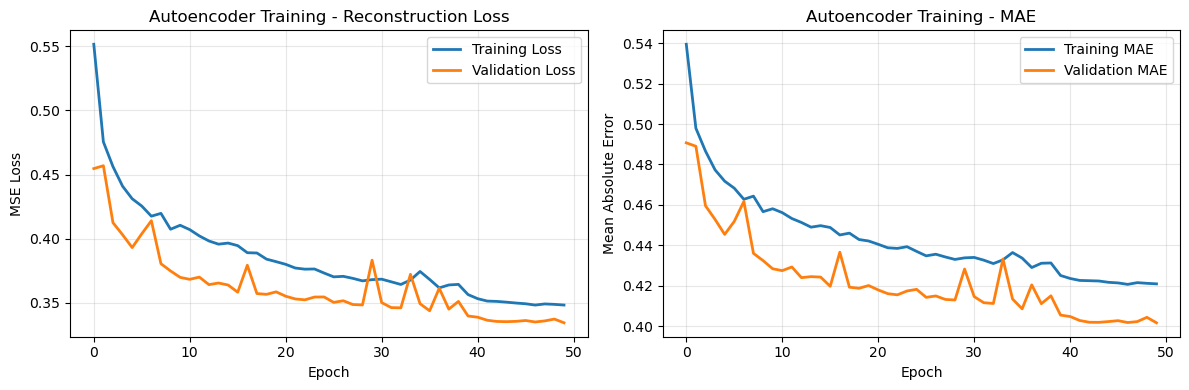

📊 Final Training Loss: 0.348268
📊 Final Validation Loss: 0.334431
📊 Overfitting ratio: 1.041


In [ ]:
def plot_training_progress(history):
    """Plot and save training and validation loss/metrics for the run.

    Produces side-by-side plots for reconstruction loss (MSE) and MAE,
    saves the figure to `reports/figures/autoencoder_training_curves.png`,
    and prints final training metrics and a simple overfitting ratio.

    Args:
        history (keras.callbacks.History): Training history returned by `fit`.

    Returns:
        None
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('Autoencoder Training - Reconstruction Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('MSE Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # MAE plot
    ax2.plot(history.history.get('mae', []), label='Training MAE', linewidth=2)
    ax2.plot(history.history.get('val_mae', []), label='Validation MAE', linewidth=2)
    ax2.set_title('Autoencoder Training - MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Mean Absolute Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    reports_dir = Path("reports/figures")
    reports_dir.mkdir(exist_ok=True, parents=True)
    plt.savefig(reports_dir / "autoencoder_training_curves.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Final metrics
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    print(f"📊 Final Training Loss: {final_train_loss:.6f}")
    print(f"📊 Final Validation Loss: {final_val_loss:.6f}")
    print(f"📊 Overfitting ratio: {final_train_loss/final_val_loss:.3f}")

# Plot results
plot_training_progress(history)

2.5 Model Saving & Latent Space Analysis


💾 Saving models...


✅ All models and artifacts saved

🔹 Analyzing latent space...
🔍 Latent space analysis:
   Shape: (1000, 30)
   Mean activation: 4.2294
   Std activation: 2.5186
   Sparsity (% zeros): 3.59%


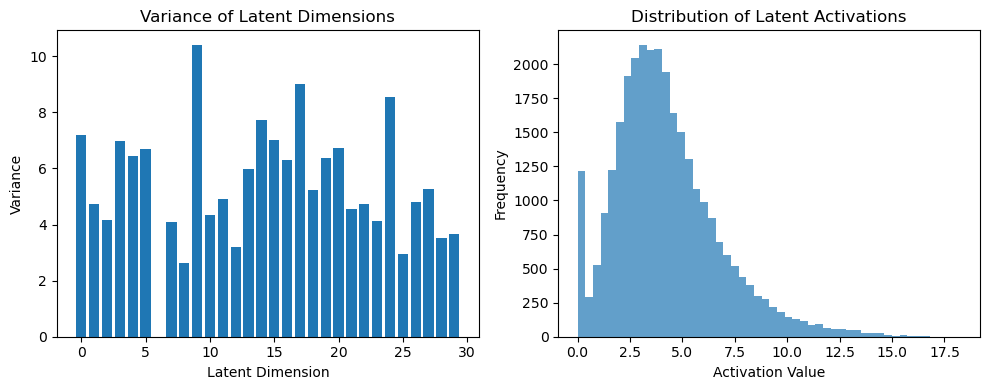

18999

In [ ]:
def save_models_and_artifacts(autoencoder, encoder, decoder, history):
    """Persist trained models and training artifacts to the `models` folder.

    Saves the full autoencoder, the encoder and decoder separately, and
    stores a CSV of the training history so downstream steps can reproduce
    analyses and continue training if needed.

    Args:
        autoencoder (keras.Model): Trained full autoencoder to save.
        encoder (keras.Model): Trained encoder used for feature extraction.
        decoder (keras.Model): Trained decoder for reconstruction/generation.
        history (keras.callbacks.History): Training history to export.

    Returns:
        None

    Raises:
        OSError: If saving to disk fails (e.g., permission or path issues).
    """
    
    models_dir = Path("models")
    models_dir.mkdir(exist_ok=True)
    
    # Save models in multiple formats for flexibility
    print("💾 Saving models...")
    
    # Save full autoencoder
    autoencoder.save(models_dir / "autoencoder_full.h5")
    
    # Save encoder (for feature extraction)
    encoder.save(models_dir / "encoder.h5")
    
    # Save decoder (for potential generation tasks)
    decoder.save(models_dir / "decoder.h5")
    
    # Save training history
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(models_dir / "training_history.csv", index=False)
    
    print("✅ All models and artifacts saved")

def analyze_latent_space(encoder, X_sample):
    """Compute and visualize properties of the encoder's latent space.

    Extracts latent representations for a sample subset, reports basic
    statistics (shape, mean, std, sparsity), and saves plots that help
    evaluate whether the bottleneck features are informative and varied.

    Args:
        encoder (keras.Model): Encoder model mapping input -> latent.
        X_sample (np.ndarray): Input examples to analyze (samples x features).

    Returns:
        np.ndarray: Latent representations for the provided sample inputs.

    Raises:
        ValueError: If `X_sample` has fewer rows than the analysis sample size.
    """
    
    # Extract latent features for a sample
    latent_representations = encoder.predict(X_sample[:1000], verbose=0)  # Small sample for analysis
    
    print(f"🔍 Latent space analysis:")
    print(f"   Shape: {latent_representations.shape}")
    print(f"   Mean activation: {latent_representations.mean():.4f}")
    print(f"   Std activation: {latent_representations.std():.4f}")
    print(f"   Sparsity (% zeros): {(latent_representations == 0).mean():.2%}")
    
    # Plot latent dimension variances
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(latent_representations.shape[1]), latent_representations.var(axis=0))
    plt.title('Variance of Latent Dimensions')
    plt.xlabel('Latent Dimension')
    plt.ylabel('Variance')
    
    plt.subplot(1, 2, 2)
    plt.hist(latent_representations.flatten(), bins=50, alpha=0.7)
    plt.title('Distribution of Latent Activations')
    plt.xlabel('Activation Value')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.savefig("reports/figures/latent_space_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    return latent_representations

# Save everything
save_models_and_artifacts(autoencoder, encoder, decoder, history)

# Analyze latent space
print("\n🔹 Analyzing latent space...")
latent_sample = analyze_latent_space(encoder, X_train)

# Free up memory
del X_train, latent_sample
gc.collect()

2.6 Leukemia Data Feature Extraction


In [ ]:
def extract_leukemia_features():
    """Load leukemia expression data, transform with saved scaler, and extract latent features.

    This function reads leukemia gene-expression and sample metadata, loads
    the previously fitted scaler and encoder, transforms the leukemia data
    into the encoder's latent space, attaches disease labels, and saves
    the resulting feature table for downstream classification tasks.

    Args:
        None

    Returns:
        pandas.DataFrame: DataFrame with latent features, `disease` label and `sample_id`.

    Raises:
        FileNotFoundError: If leukemia input files or saved models/scaler are missing.
    """
    
    print("🔹 Processing leukemia data for feature extraction...")
    
    # Load leukemia data
    leukemia_path = Path("../data/processed/leukemia_filtered.csv")
    leukemia_df = pd.read_csv(leukemia_path, index_col=0)
    
    # Load metadata
    metadata_path = Path("../data/processed/leukemia_sample_info.csv") 
    metadata_df = pd.read_csv(metadata_path)
    
    print(f"📊 Leukemia data: {leukemia_df.shape}")
    
    # Load scaler and transform
    scaler = joblib.load(Path("models/scaler.joblib"))
    X_leukemia = scaler.transform(leukemia_df.values.astype('float32'))
    
    # Load encoder
    encoder = keras.models.load_model(Path("models/encoder.h5"))
    
    # Extract latent features
    print("🔹 Extracting latent features...")
    leukemia_latent = encoder.predict(X_leukemia, batch_size=32, verbose=1)
    
    # Create feature dataframe
    latent_cols = [f'latent_{i:02d}' for i in range(leukemia_latent.shape[1])]
    latent_df = pd.DataFrame(leukemia_latent, columns=latent_cols, index=leukemia_df.index)
    
    # Combine with metadata
    final_df = latent_df.copy()
    final_df['disease'] = metadata_df.set_index('sample')['disease']
    final_df['sample_id'] = final_df.index
    
    # Save extracted features
    features_path = Path("../data/processed/leukemia_latent_features.csv")
    final_df.to_csv(features_path)
    
    print(f"✅ Leukemia features extracted and saved: {final_df.shape}")
    print(f"💡 Features: {leukemia_latent.shape[1]} latent dimensions + disease labels")
    
    return final_df

# Extract features for next phase
leukemia_features = extract_leukemia_features()

print("\n" + "="*60)
print("🎉 PHASE 2 COMPLETED SUCCESSFULLY!")
print("="*60)

🔹 Processing leukemia data for feature extraction...


📊 Leukemia data: (357, 20034)
🔹 Extracting latent features...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
✅ Leukemia features extracted and saved: (357, 32)
💡 Features: 30 latent dimensions + disease labels

🎉 PHASE 2 COMPLETED SUCCESSFULLY!


2.7 Testing

In [ ]:
# 🧪 QUICK VALIDATION TEST
def quick_reconstruction_test():
    """Run a quick reconstruction quality check for the autoencoder.

    Reconstructs a small batch of training samples, computes per-sample
    Pearson correlations between original and reconstructed vectors, and
    reports the average correlation. Returns True when reconstruction is
    reasonably good (avg correlation > 0.7) and False otherwise.

    Args:
        None

    Returns:
        bool: True if reconstruction quality passes the threshold, else False.
    """
    sample_data = X_train[:20]
    reconstructions = autoencoder.predict(sample_data, verbose=0)
    
    correlations = []
    for i in range(len(sample_data)):
        corr = np.corrcoef(sample_data[i], reconstructions[i])[0,1]
        correlations.append(corr)
    
    avg_correlation = np.mean(correlations)
    print(f"📊 Reconstruction Correlation: {avg_correlation:.4f}")
    
    if avg_correlation > 0.7:
        print("✅ PASS: Good reconstruction quality")
        return True
    else:
        print("❌ FAIL: Poor reconstruction quality")
        return False

test_passed = quick_reconstruction_test()

📊 Reconstruction Correlation: 0.7828
✅ PASS: Good reconstruction quality
